# Arcitecture of Multihead Attention



```
                                        X
                                    (3×4)
                                      │
                            ┌──────────┴───────────┐
                            │                      │
                        Head-1                 Head-2
                        (Q,K,V)                (Q,K,V)
                            │                      │
                            ▼                      ▼
                        Attention              Attention
                            │                      │
                            ▼                      ▼
                        Output1               Output2
                        (3×2)                 (3×2)
                              \                /
                              \              /
                                Concatenate
                                  (3×4)
                                      │
                                      ▼
                                Linear Layer
                                W_O (4×4)
                                      │
                                      ▼
                                Final Output
                                (3×4)
```



# Identify head and dimension

In [1]:
import torch
import torch.nn as nn

In [2]:
embed_dim = 8
num_heads = 2

head_dim = embed_dim // num_heads

print(head_dim)

4


In [9]:

x=torch.randn(2,3,4) #(batch_size,seq_len,embed_dim)
print(x.shape)
print(x)

torch.Size([2, 3, 4])
tensor([[[-0.8359,  0.4581,  1.3411, -1.4052],
         [-0.1400, -0.4571, -0.2273,  1.1054],
         [-0.4990,  0.2080, -0.7211, -1.5119]],

        [[-0.4325, -0.4714, -1.4997,  0.8177],
         [ 0.4515, -0.1910, -0.2924, -0.8032],
         [ 0.9911, -1.5711, -1.0533,  0.9061]]])


## Split

In [13]:
x=x.view(2,3,2,2)
print(x)

tensor([[[[-0.8359,  0.4581],
          [ 1.3411, -1.4052]],

         [[-0.1400, -0.4571],
          [-0.2273,  1.1054]],

         [[-0.4990,  0.2080],
          [-0.7211, -1.5119]]],


        [[[-0.4325, -0.4714],
          [-1.4997,  0.8177]],

         [[ 0.4515, -0.1910],
          [-0.2924, -0.8032]],

         [[ 0.9911, -1.5711],
          [-1.0533,  0.9061]]]])


In [15]:
print(x.shape)

torch.Size([2, 3, 2, 2])


(2,3,2,2)
(batch,seq_len,heads,head_dim)

## Transpose

In [18]:
x=x.transpose(1,2)
print(x)

tensor([[[[-0.8359,  0.4581],
          [-0.1400, -0.4571],
          [-0.4990,  0.2080]],

         [[ 1.3411, -1.4052],
          [-0.2273,  1.1054],
          [-0.7211, -1.5119]]],


        [[[-0.4325, -0.4714],
          [ 0.4515, -0.1910],
          [ 0.9911, -1.5711]],

         [[-1.4997,  0.8177],
          [-0.2924, -0.8032],
          [-1.0533,  0.9061]]]])


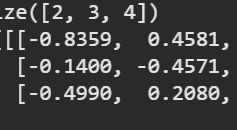

In [19]:
x.shape

torch.Size([2, 2, 3, 2])

[2, 2, 3, 2]-->(batch,heads,seq_len,head_dim)

## Dimension Flow



```
Original

(2,3,4)

      │

view()

      ▼

(2,3,2,2)

      │

transpose()

      ▼

(2,2,3,2)
```



একটি Attention Head একটি নির্দিষ্ট ধরনের সম্পর্ক শিখতে পারে।

কিন্তু Multi-Head Attention-এ বিভিন্ন Head একসাথে বিভিন্ন সম্পর্ক শেখে।

| Head   | কী শিখতে পারে                         |
| ------ | ------------------------------------- |
| Head-1 | Subject ↔ Verb সম্পর্ক                |
| Head-2 | Object ↔ Verb সম্পর্ক                 |
| Head-3 | Long-distance dependency              |
| Head-4 | Semantic similarity                   |
| Head-5 | Negation ("not", "never")             |
| Head-6 | Pronoun reference ("he", "she", "it") |


এগুলো আগে থেকে নির্ধারণ করা থাকে না। Training-এর সময় প্রতিটি Head নিজে নিজেই ভিন্ন ধরনের pattern শিখে।

# Multihead Attention Class

In [20]:
import math
import torch
import torch.nn as nn

In [31]:
class MultiHeadAttention(nn.Module):
  def __init__(self,embed_dim,num_heads):
    super().__init__()

    self.embed_dim=embed_dim
    self.num_heads=num_heads
    self.head_dim=embed_dim//num_heads

    self.query=nn.Linear(embed_dim,embed_dim,bias=False)
    self.key=nn.Linear(embed_dim,embed_dim,bias=False)
    self.value=nn.Linear(embed_dim,embed_dim,bias=False)

    self.fc_out=nn.Linear(embed_dim,embed_dim)

  def forward(self,x):
    B,S,E=x.shape   #(batch,seq_len,embed_dim)

    Q=self.query(x) #(batch,seq_len,embed_dim)
    K=self.key(x)   #(batch,seq_len,embed_dim)
    V=self.value(x) #(batch,seq_len,embed_dim)

    print("Shape of Q:",Q.shape)
    print("="*60)

    # split into heads
    Q=Q.view(B,S,self.num_heads,self.head_dim)
    K=K.view(B,S,self.num_heads,self.head_dim)
    V=V.view(B,S,self.num_heads,self.head_dim)
    # shape of Q,K,V (batch,seq_len,numOfheads,head_dim)
    print("\nAfter View The shape of Q:",Q.shape)
    print("="*60)

    Q=Q.transpose(1,2)
    K=K.transpose(1,2)
    V=V.transpose(1,2)
    #after transpose shape of Q,K,V (batch,numOfHeads,seq_len,head_dim)
    print("\nAfter Transpose The shape of Q:",Q.shape)
    print("="*60)

    # scores
    scores=torch.matmul(
        Q,K.transpose(-2,-1)
    )
    print("\nScores: ",scores.shape)

    # scaling
    scores=scores/math.sqrt(self.head_dim)

    # attention weight
    attention=torch.softmax(
        scores,
        dim=-1
    )

    # context
    context=torch.matmul(
        attention,
        V
    )

    print("\nContext Shape :",context.shape)
    print("="*50)

    context=context.transpose(1,2)
    # before transpose shape of context(B,H,S,D)
    # after transpose shape of context(B,S,H,D)

    context=context.contiguous()
    # Merge
    context=context.view(
        B,S,self.embed_dim
    )
    print("\nMerged context shape :",context.shape)
    print("="*50)

    output=self.fc_out(context)
    print("\nOutput Shape :",output.shape)
    print("="*50)
    return output





## Test code

In [32]:
torch.manual_seed(42)
x=torch.randn(
    2,5,8
)
print(x)

tensor([[[ 1.9269,  1.4873,  0.9007, -2.1055,  0.6784, -1.2345, -0.0431,
          -1.6047],
         [-0.7521,  1.6487, -0.3925, -1.4036, -0.7279, -0.5594, -0.7688,
           0.7624],
         [ 1.6423, -0.1596, -0.4974,  0.4396, -0.7581,  1.0783,  0.8008,
           1.6806],
         [ 1.2791,  1.2964,  0.6105,  1.3347, -0.2316,  0.0418, -0.2516,
           0.8599],
         [-1.3847, -0.8712, -0.2234,  1.7174,  0.3189, -0.4245,  0.3057,
          -0.7746]],

        [[-1.5576,  0.9956, -0.8798, -0.6011, -1.2742,  2.1228, -1.2347,
          -0.4879],
         [-0.9138, -0.6581,  0.0780,  0.5258, -0.4880,  1.1914, -0.8140,
          -0.7360],
         [-1.4032,  0.0360, -0.0635,  0.6756, -0.0978,  1.8446, -1.1845,
           1.3835],
         [ 1.4451,  0.8564,  2.2181,  0.5232,  0.3466, -0.1973, -1.0546,
           1.2780],
         [-0.1722,  0.5238,  0.0566,  0.4263,  0.5750, -0.6417, -2.2064,
          -0.7508]]])


In [33]:
model=MultiHeadAttention(
    embed_dim=8,
    num_heads=2
)
output=model(x)

Shape of Q: torch.Size([2, 5, 8])

After View The shape of Q: torch.Size([2, 5, 2, 4])

After Transpose The shape of Q: torch.Size([2, 2, 5, 4])

Scores:  torch.Size([2, 2, 5, 5])

Context Shape : torch.Size([2, 2, 5, 4])

Merged context shape : torch.Size([2, 5, 8])

Output Shape : torch.Size([2, 5, 8])


# Full multiheadAttention Flow for pytorch Implementation



```
Input X
(2,3,4)
      │
      ▼
Linear Q,K,V
(2,3,4)
      │
      ▼
Reshape
(2,3,2,2)
      │
      ▼
Transpose
(2,2,3,2)
      │
      ▼
Q×Kᵀ
(2,2,3,3)
      │
      ▼
Softmax
(2,2,3,3)
      │
      ▼
× V
(2,2,3,2)
      │
      ▼
Transpose Back
(2,3,2,2)
      │
      ▼
Reshape
(2,3,4)
      │
      ▼
Linear Wₒ
(2,3,4)
```





---



---
Z.I. Turjo

